In [9]:
import pymysql

conn = pymysql.connect(
    host='localhost',
    user='user',
    password='1234',
    database='ontime',
    charset='utf8'
)
print('DB 접속 성공')


DB 접속 성공


In [10]:
cursor = conn.cursor()
cursor.execute('select * from ontime limit 5')
rows = cursor.fetchall()
for row in rows:
    print(row)

(2007, 1, 1, 1, 1232, 1225, 1341, 1340, 'WN', 2891, 'N351', 69, 75, 54, 1, 7, 'SMF', 'ONT', 389, 4, 11, 0, '', '0', 0, 0, 0, 0, 0, 1)
(2007, 1, 16, 2, 851, 845, 1404, 1410, 'WN', 1325, 'N725', 193, 205, 181, -6, 6, 'LAS', 'MDW', 1521, 4, 8, 0, '', '0', 0, 0, 0, 0, 0, 2)
(2007, 1, 16, 2, 1606, 1610, 2132, 2140, 'WN', 1461, 'N240', 206, 210, 178, -8, -4, 'LAS', 'MDW', 1521, 6, 22, 0, '', '0', 0, 0, 0, 0, 0, 3)
(2007, 1, 1, 1, 1918, 1905, 2043, 2035, 'WN', 462, 'N370', 85, 90, 74, 8, 13, 'SMF', 'PDX', 479, 5, 6, 0, '', '0', 0, 0, 0, 0, 0, 4)
(2007, 1, 16, 2, 0, 1700, 0, 2230, 'WN', 1988, '0', 0, 210, 0, 0, 0, 'LAS', 'MDW', 1521, 0, 0, 1, 'A', '0', 0, 0, 0, 0, 0, 5)


In [14]:
cursor = conn.cursor()
cursor.execute('''
select a.year, a.uniquecarrier, c.description, count(*)
from ontime a, carrier c
where a.uniquecarrier=c.code
and a.arrdelay>0
group by a.year, a.uniquecarrier, c.description
order by count(*)
''')
rows = cursor.fetchall()
for row in rows:
    print(row)

(2007, 'AQ', 'Aloha Airlines Inc.', 12785)
(2007, 'HA', 'Hawaiian Airlines Inc.', 14379)
(2007, 'F9', 'Frontier Airlines Inc.', 49315)
(2007, 'AS', 'Alaska Airlines Inc.', 76651)
(2007, 'B6', 'JetBlue Airways', 87837)
(2007, '9E', 'Pinnacle Airlines Inc.', 106775)
(2007, 'FL', 'AirTran Airways Corporation', 114196)
(2007, 'OH', 'Comair Inc.', 119104)
(2007, 'YV', 'Mesa Airlines Inc.', 124259)
(2007, 'CO', 'Continental Air Lines Inc.', 146090)
(2007, 'EV', 'Atlantic Southeast Airlines', 150573)
(2007, 'XE', 'Expressjet Airlines Inc.', 177060)
(2007, 'DL', 'Delta Air Lines Inc.', 217610)
(2007, 'NW', 'Northwest Airlines Inc.', 232834)
(2007, 'UA', 'United Air Lines Inc.', 233395)
(2007, 'MQ', 'American Eagle Airlines Inc.', 249922)
(2007, 'US', 'US Airways Inc. (Merged with America West 9/05. Reporting for both starting 10/07.)', 259400)
(2007, 'OO', 'Skywest Airlines Inc.', 275732)
(2007, 'AA', 'American Airlines Inc.', 315224)
(2007, 'WN', 'Southwest Airlines Co.', 490314)


In [16]:
cursor.execute('''
select uniquecarrier, avg(arrdelay)
from ontime
group by uniquecarrier
''')
rows = cursor.fetchall()
for row in rows:
    print(row)

('WN', Decimal('5.4172'))
('YV', Decimal('10.5248'))
('OO', Decimal('8.6170'))
('UA', Decimal('12.4171'))
('OH', Decimal('12.6116'))
('US', Decimal('11.2930'))
('DL', Decimal('7.1869'))
('XE', Decimal('9.7201'))
('EV', Decimal('16.6180'))
('MQ', Decimal('12.4089'))
('AA', Decimal('13.9857'))
('F9', Decimal('7.3930'))
('CO', Decimal('10.1419'))
('FL', Decimal('7.8387'))
('NW', Decimal('12.2969'))
('HA', Decimal('-0.4287'))
('AQ', Decimal('-1.3649'))
('AS', Decimal('9.0857'))
('9E', Decimal('7.8659'))
('B6', Decimal('13.1357'))


In [26]:
cursor.execute('''select month, count(*)
               from ontime
               where year=2007 and arrdelay>0
               group by month''')
rows=cursor.fetchall()
print(rows)
for row in rows:
    print(row)

((1, 286334), (2, 284152), (3, 293360), (4, 273055), (5, 275332), (6, 326446), (7, 326559), (8, 317197), (9, 225751), (10, 270098), (11, 242722), (12, 332449))
(1, 286334)
(2, 284152)
(3, 293360)
(4, 273055)
(5, 275332)
(6, 326446)
(7, 326559)
(8, 317197)
(9, 225751)
(10, 270098)
(11, 242722)
(12, 332449)


In [28]:
import matplotlib.pyplot as plt

x=list(range(1,13))
y=[]
for row in rows:
    y.append(row[1])
print(x)
print(y)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
[286334, 284152, 293360, 273055, 275332, 326446, 326559, 317197, 225751, 270098, 242722, 332449]


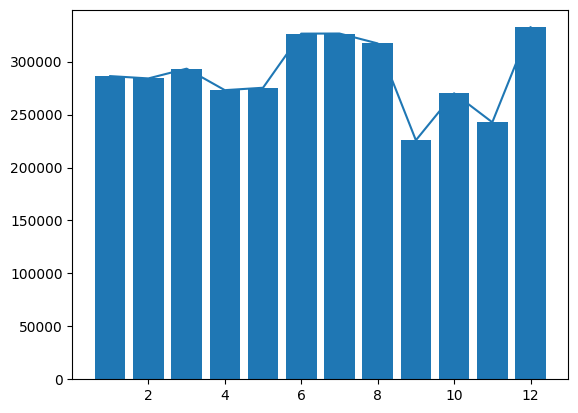

In [30]:
plt.plot(x,y)
plt.bar(x,y)
plt.show()

In [31]:
cursor.execute('''select dayofweek, avg(arrdelay)
               from ontime
               group by dayofweek
               order by dayofweek''')
rows = cursor.fetchall()
for row in rows:
    print(row)

(1, Decimal('10.2803'))
(2, Decimal('8.0476'))
(3, Decimal('9.6975'))
(4, Decimal('12.3632'))
(5, Decimal('12.7477'))
(6, Decimal('5.7356'))
(7, Decimal('10.0972'))


In [35]:
x=['일','월','화','수','목','금','토']
y=[]
for row in rows:
    y.append(row[1])
print(x,y)

['일', '월', '화', '수', '목', '금', '토'] [Decimal('10.2803'), Decimal('8.0476'), Decimal('9.6975'), Decimal('12.3632'), Decimal('12.7477'), Decimal('5.7356'), Decimal('10.0972')]


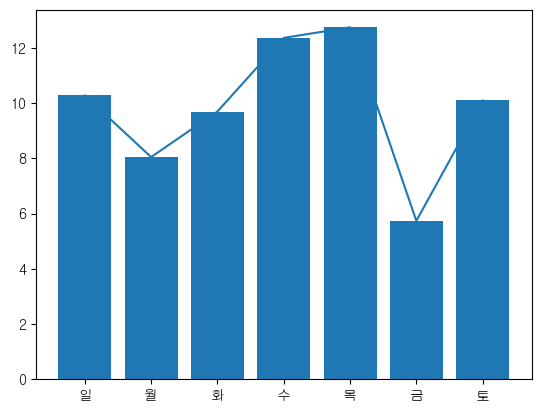

In [37]:
import matplotlib.pyplot as plt

from matplotlib import rc,font_manager
font_name=font_manager.FontProperties(fname='c:/windows/fonts/gulim.ttc').get_name()
rc('font',family=font_name)

plt.plot(x,y)
plt.bar(x,y)
plt.show()

In [44]:
cursor.execute('''select CRSDepTime, avg(arrdelay) arrdelay
               from ontime
               where month=10 and dayofweek=2
               group by CRSDepTime
               order by arrdelay
               limit 10''')
rows = cursor.fetchall()
for row in rows:
    print(row)

(1924, Decimal('-34.0000'))
(2352, Decimal('-33.0000'))
(300, Decimal('-32.8000'))
(2231, Decimal('-24.0000'))
(1801, Decimal('-22.0000'))
(549, Decimal('-21.0000'))
(2038, Decimal('-20.8333'))
(634, Decimal('-19.5000'))
(542, Decimal('-18.8000'))
(2310, Decimal('-17.2500'))
